In [23]:
#Data Analysis and Manipulation
import numpy as np
import pandas as pd

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns



In [24]:
#Load data as a dataframe in Pandas and provide general findings
df=pd.read_csv("C:/Users/raiya/OneDrive/Desktop/loan_data_with_nulls_and_errors.csv",encoding="ISO-8859-1")
df.head()



,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,32.0,male,Associate,96865.0,10.0,MORTGAGE,7500.0,EDUCATION,6.04,0.08,10.0,601.0,No,0.0
1,24.0,male,Associate,56838.0,6.0,RENT,9000.0,EDUCATION,11.49,0.16,4.0,647.0,Yes,0.0
2,22.0,female,Master,37298.0,0.0,RENT,5000.0,MEDICAL,14.88,0.13,4.0,711.0,No,1.0
3,23.0,female,Bachelor,39944.0,1.0,OWN,5000.0,VENTURE,13.99,0.13,3.0,597.0,Yes,0.0
4,42.0,male,High School,67974.0,20.0,MORTGAGE,10000.0,HOMEIMPROVEMENT,15.41,0.15,11.0,586.0,NaN,1.0


In [25]:
df.info()# Provides no of row, columns, data and non- null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      42785 non-null  float64
 1   person_gender                   42749 non-null  object 
 2   person_education                42737 non-null  object 
 3   person_income                   42833 non-null  float64
 4   person_emp_exp                  42810 non-null  float64
 5   person_home_ownership           42788 non-null  object 
 6   loan_amnt                       42768 non-null  float64
 7   loan_intent                     42776 non-null  object 
 8   loan_int_rate                   42663 non-null  float64
 9   loan_percent_income             42750 non-null  float64
 10  cb_person_cred_hist_length      42806 non-null  float64
 11  credit_score                    42803 non-null  float64
 12  previous_loan_defaults_on_file  

In [26]:
df.describe()# Provide statistical summary

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,42785.000000,4.283300e+04,42810.000000,42768.000000,42663.000000,42750.000000,42806.000000,42803.000000,42815.000000
mean,27.766554,8.036982e+04,5.402710,9586.156963,11.007475,0.139805,5.865696,632.572180,0.222002
std,6.047741,8.129813e+04,6.072947,6315.704790,2.979069,0.087345,3.873791,50.478743,0.415597
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.722200e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.705600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578300e+04,8.000000,12250.000000,13.010000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [27]:
df.isnull().sum() #Check the total number of null values in each column



person_age                        2215
person_gender                     2251
person_education                  2263
person_income                     2167
person_emp_exp                    2190
person_home_ownership             2212
loan_amnt                         2232
loan_intent                       2224
loan_int_rate                     2337
loan_percent_income               2250
cb_person_cred_hist_length        2194
credit_score                      2197
previous_loan_defaults_on_file    2274
loan_status                       2185
dtype: int64

In [28]:
duplicate_values=df.duplicated().sum() # Check for duplicated values
print(duplicate_values)

0


In [29]:
null_values=df.isna().mean()*100# % of missing values for each column
print(null_values)

person_age                        4.922222
person_gender                     5.002222
person_education                  5.028889
person_income                     4.815556
person_emp_exp                    4.866667
person_home_ownership             4.915556
loan_amnt                         4.960000
loan_intent                       4.942222
loan_int_rate                     5.193333
loan_percent_income               5.000000
cb_person_cred_hist_length        4.875556
credit_score                      4.882222
previous_loan_defaults_on_file    5.053333
loan_status                       4.855556
dtype: float64


In [30]:
#Data Preprocessing: 

#1. Column-Wise Missing Value Treatment

#   Age : null values filled with median of the column value
no_null_age=df['person_age'].fillna(df['person_age'].median(),inplace=True )


#   Home Ownership: 
# Encode null value= OWN:0, RENT: 1, MORTGAGE: 3 
df['person_home_ownership'].value_counts(dropna=False) #This helps catch values like "Own", "RENT ", "Mortgage", or "OTHER"
person_house_ownership_encode={
    'OWN':0,
    'RENT':1,
    'MORTGAGE':2
    
}
df['person_home_ownership']=df['person_home_ownership'].map(person_house_ownership_encode)
# fill null values with unknown 
df['person_home_ownership'].fillna('Unknown',inplace=True)




#   Person Education: fill null values with unknown
df['person_education'].fillna('Unknown',inplace=True)


#   Income : Create new flag table + fill null values with encoding 0 for filled and 1 for null
#Flag column created for missing values.Why Flag?: Income missing often signals financial instability (MNAR)
df['income_missing']=df['person_income'].isna().astype(int) #astype(int) fills null values with 1 and filled with 0
#Fill the missing income values with median income 
df['person_income'].fillna(df['person_income'].median(), inplace=True )



#   Employment Experience: Null values filled with 0
df['person_emp_exp'].fillna(0,inplace=True)


#   Credit Score: flag null values + fill null with median of dataset
#Missing credit score is a strong risk signal
df['credit_score_missing']=df['credit_score'].isna().astype(int) 
df['credit_score'].fillna(df['credit_score'].median(), inplace=True)
# Drops entire row from the DataFrame where the value in the loan_amnt column is missing (NaN).
df=df.dropna(subset=['loan_amnt']) 



#   Loan Interest Rate
#It fills missing interest rates (loan_int_rate) using the median interest rate of the same credit score.
df['loan_int_rate'].fillna(df.groupby('credit_score')['loan_int_rate'].transform('median'),inplace=True)


#   Gender: 
#Remove extra white spacce and convert all to lowercase. Then fill null values with 'Unknown'
df['person_gender']=df['person_gender'].str.strip().str.lower()
df['person_gender'].fillna('Unknown',inplace=True)
#Encode gender categorical data with male 1, female 0 
gender_encode={
    'male': 1,
    'm':1,
    'female':0,
    'f':0
}
df['gender_encoded']=df['person_gender'].map(gender_encode)
df=df.dropna(subset=['gender_encoded']) 
df = df.drop('person_gender', axis=1)


#   Loan Intent:
#Drop null values for which loan intention is unknown
df=df.dropna(subset=['loan_intent']) 


#   Loan Status: drop missing values
df=df.dropna(subset=['loan_status'])


#   Previous Loan Default:
#Encode 1 with yes and 0 with no
person_previous_loan_default_encode={
    'Yes': 1,
    'No':0,
    
}
df['previous_loan_defaults_on_file']=df['previous_loan_defaults_on_file'].map(person_previous_loan_default_encode)
df=df.dropna(subset=['previous_loan_defaults_on_file'])



#Loan Percent Income: drop null values
df=df.dropna(subset=['loan_percent_income'])




df.isna().sum()

C:\Users\raiya\AppData\Local\Temp\ipykernel_16252\3118016682.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  no_null_age=df['person_age'].fillna(df['person_age'].median(),inplace=True )
C:\Users\raiya\AppData\Local\Temp\ipykernel_16252\3118016682.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

person_age                           0
person_education                     0
person_income                        0
person_emp_exp                       0
person_home_ownership                0
loan_amnt                            0
loan_intent                          0
loan_int_rate                        0
loan_percent_income                  0
cb_person_cred_hist_length        1649
credit_score                         0
previous_loan_defaults_on_file       0
loan_status                          0
income_missing                       0
credit_score_missing                 0
gender_encoded                       0
dtype: int64

In [31]:
# Data Analysis and Visualization

#1. No of loans paid vs No of Loan defaults as a %
df['loan_status'].value_counts(normalize=True,sort=True)
#normalize=True returns percentage rather than raw count


loan_status
0.0    0.777731
1.0    0.222269
Name: proportion, dtype: float64

<Axes: xlabel='loan_status', ylabel='count'>

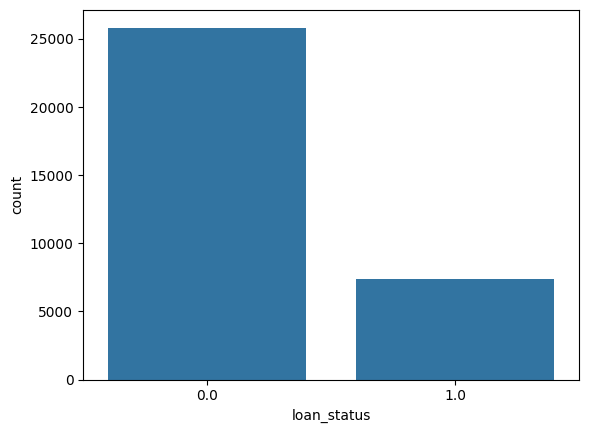

In [32]:
#Essentially a bar plot specifically designed to show the frequency distribution of categorical data here
sns.countplot(x='loan_status', data=df)
#Loan paid vs Loan Defaults

Text(0, 0.5, 'No of Loan Applicants')

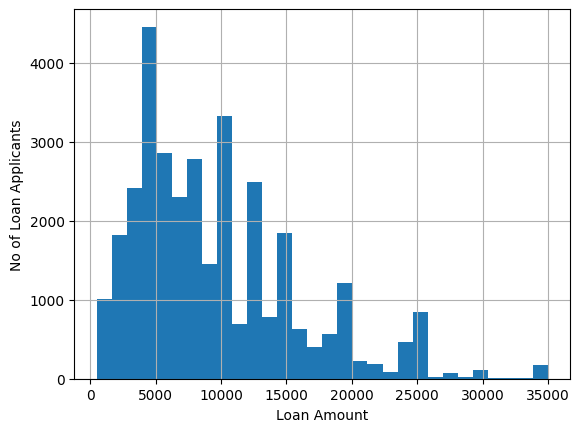

In [33]:
#Histogram
df['loan_amnt'].hist(bins=30,label='Loan Amount Taken by Borrowers')
plt.xlabel('Loan Amount')
plt.ylabel('No of Loan Applicants')

<Axes: xlabel='loan_amnt'>

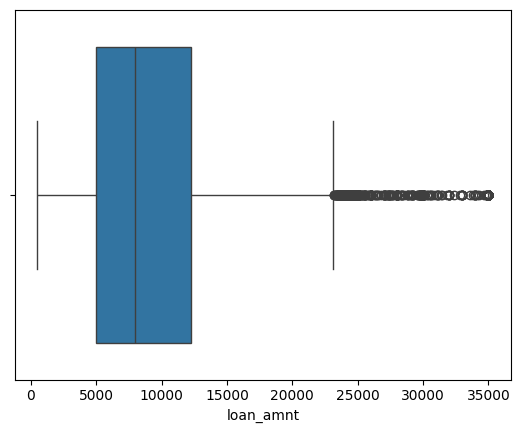

In [34]:
#Boxplot
sns.boxplot(x=df['loan_amnt'])

<Axes: xlabel='person_income', ylabel='loan_amnt'>

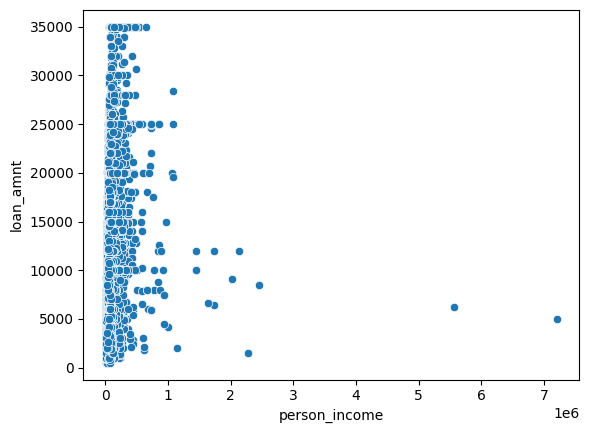

In [35]:
#Scatterplot to show relationship between income and loan amount. Here, relationship is very weak
sns.scatterplot(x=df['person_income'], y=df['loan_amnt'])

Text(0, 0.5, 'Loan Amount Taken')

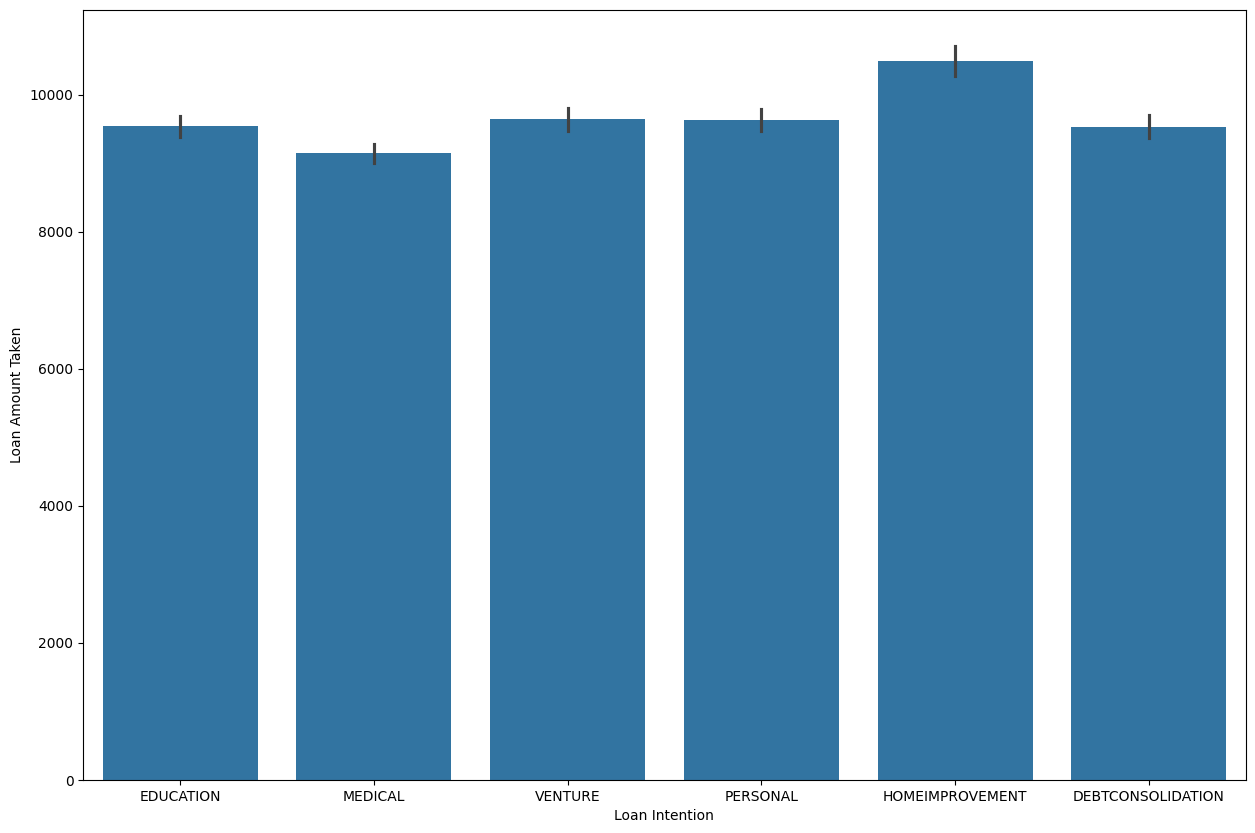

In [36]:
plt.figure(figsize=(15, 10))
sns.barplot(
    x='loan_intent',
    y='loan_amnt',
    data=df,
    estimator='mean'
    
) 
plt.xlabel('Loan Intention')
plt.ylabel('Loan Amount Taken')

Text(0.5, 1.0, 'Loan Approval by Previous Loan Default History')

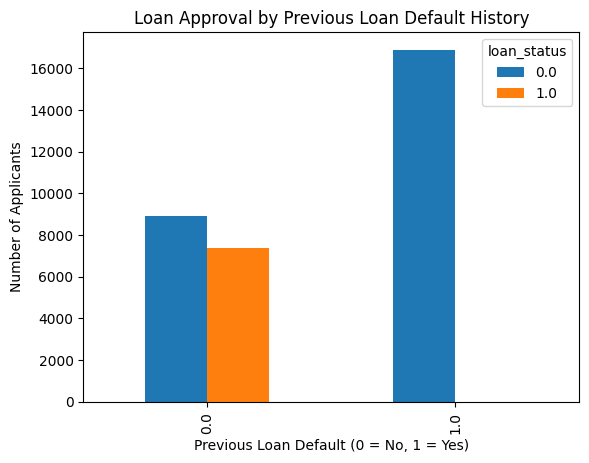

In [37]:

pd.crosstab(df["previous_loan_defaults_on_file"], df["loan_status"]).plot(kind="bar")
plt.xlabel("Previous Loan Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Applicants")
plt.title("Loan Approval by Previous Loan Default History")

In [38]:
#Prepare data for Binary Logistics Regression: 
#a) X variable: previous_loan_defaults_on_file
#b) Y variable: loan status

# Loan_Status: Yes = 1, No = 0

X = df[['previous_loan_defaults_on_file']]
y = df['loan_status']


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [41]:
#Train the Model:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
#Interpret Regression Coefficient
coef=model.coef_[0][0]
odds_ratio=np.exp(coef)

print("Coefficient:", coef)
print("Odds Ratio:", odds_ratio)



Coefficient: -7.105372205118887
Odds Ratio: 0.00082068417558728


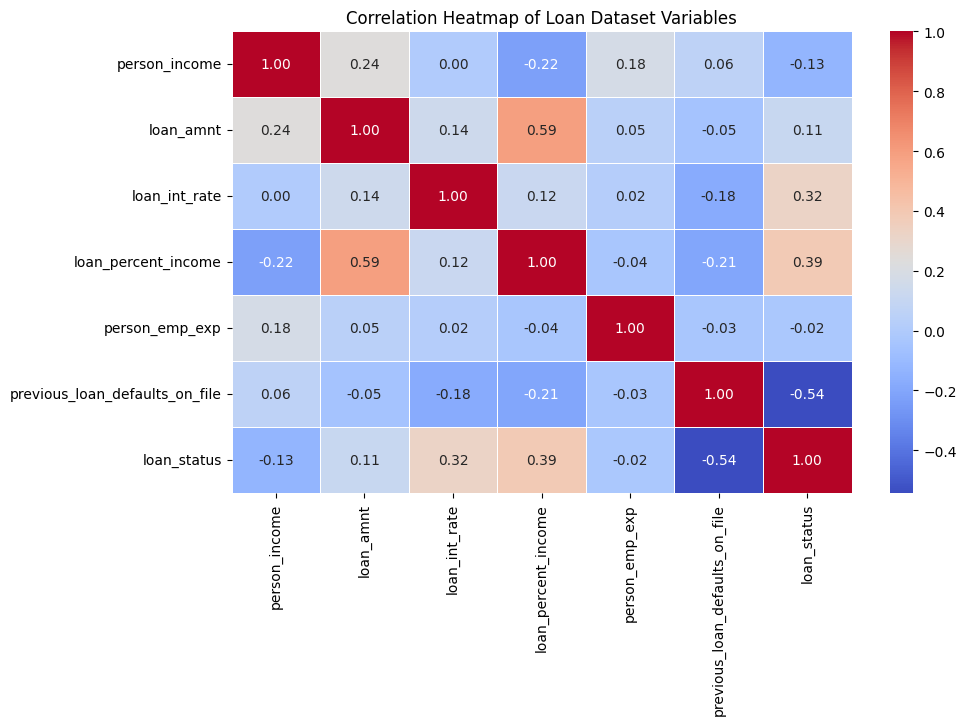

In [45]:
heatmap_vars = [
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'person_emp_exp',
    'previous_loan_defaults_on_file',
    'loan_status'
]
corr_matrix = df[heatmap_vars].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Loan Dataset Variables")
plt.show()

Text(0.5, 1.0, 'Default Rate By Loan Intention')

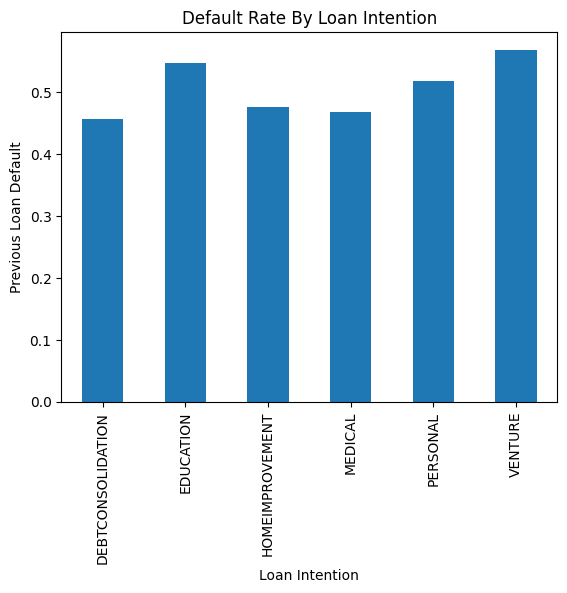

In [51]:
default_rate = df.groupby('loan_intent')['previous_loan_defaults_on_file'].mean()
default_rate.plot(kind='bar')
plt.xlabel('Loan Intention')
plt.ylabel('Previous Loan Default')
plt.title('Default Rate By Loan Intention')


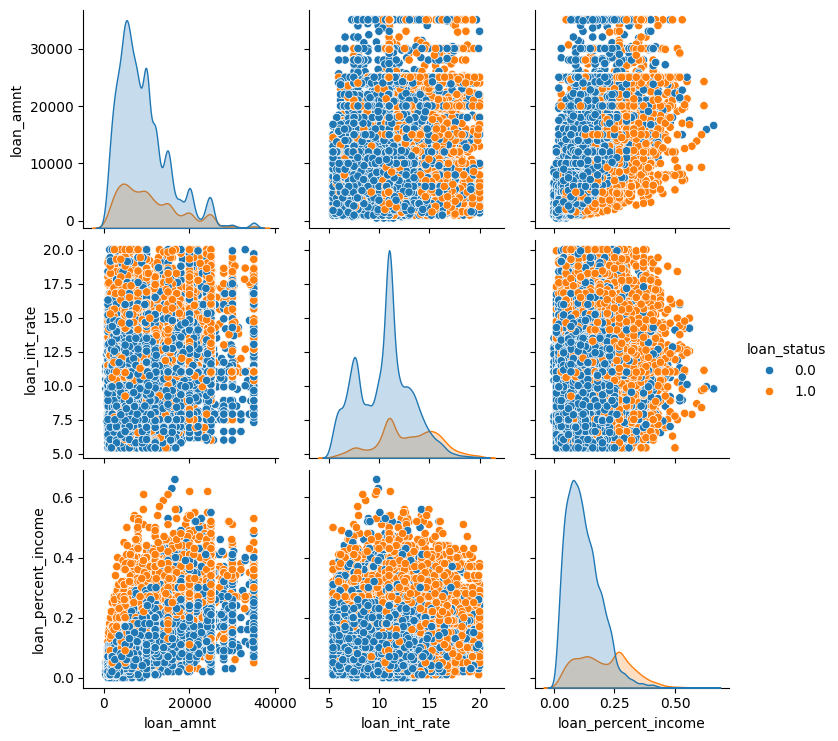

In [52]:
sns.pairplot(df[['loan_amnt','loan_int_rate','loan_percent_income','loan_status']], hue='loan_status')